# V56: Comparison - Graph Correlation Threshold Strategy

## Tujuan Eksperimen

Notebook ini membandingkan **2 strategi graph filtering** yang berbeda:

### Strategi yang Dibandingkan:

1. **V55 Momentum + Graph (Diversifikasi: korelasi ≤ 0.4)**
   - Edge: Hubungkan jika korelasi > 0.4
   - MIS: Pilih aset yang TIDAK terhubung (korelasi ≤ 0.4)
   - Tujuan: Diversifikasi maksimal

2. **V56 Momentum + Graph (Clustering: korelasi ≥ 0.4)**
   - Edge: Hubungkan jika korelasi < 0.4
   - MIS: Pilih aset yang TIDAK terhubung (korelasi ≥ 0.4)
   - Tujuan: Momentum clustering

3. **V55 Momentum + Greedy (Baseline)**
   - Tanpa graph theory
   - Greedy selection berdasarkan momentum

### Hipotesis:
- **H1:** Diversifikasi (≤ 0.4) lebih stabil, risiko lebih rendah
- **H2:** Clustering (≥ 0.4) momentum lebih kuat, tapi volatilitas lebih tinggi

### Parameter:
- AI: XGBoost (threshold optimized)
- Trend Override: SMA 50
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Correlation Threshold: 0.4
- Random Seed: 42

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# AI Training
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [4]:
# Asset Selection Methods

def get_assets_momentum_graph_diversify(returns_window, corr_threshold=0.4):
    """V55: Momentum + Graph (Diversifikasi: pilih korelasi RENDAH ≤ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Momentum
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    # Edge: Hubungkan jika korelasi TINGGI (> threshold)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    # MIS: Pilih aset yang TIDAK terhubung = korelasi RENDAH
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_momentum_graph_cluster(returns_window, corr_threshold=0.4):
    """V56: Momentum + Graph (Clustering: pilih korelasi TINGGI ≥ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Momentum
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    # Edge: Hubungkan jika korelasi RENDAH (< threshold)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    # MIS: Pilih aset yang TIDAK terhubung = korelasi TINGGI
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_momentum_greedy(returns_window, corr_threshold=0.4):
    """V55: Smart Momentum + No-Graph (Greedy)"""
    corr_mat = returns_window.corr()
    
    # Sort by Momentum
    momentum = returns_window.mean()
    sorted_assets = list(momentum.sort_values(ascending=False).index)
    
    selected = []
    for asset in sorted_assets:
        # Check if uncorrelated with already selected assets
        is_uncorrelated = True
        for selected_asset in selected:
            if abs(corr_mat.loc[asset, selected_asset]) > corr_threshold:
                is_uncorrelated = False
                break
        
        if is_uncorrelated:
            selected.append(asset)
    
    return selected

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Asset selection methods defined!")

Asset selection methods defined!


In [5]:
# Simulation Function

def run_simulation(test_dates, returns, ai_probs, threshold, market_idx, 
                   selection_func,  # Function to select assets
                   override_ma=None, 
                   fee=0.0025, 
                   g_lookback=60, 
                   rebal_period=20, 
                   turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                # USE PROVIDED SELECTION FUNCTION
                selected = selection_func(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Simulation function ready!")

Simulation function ready!


In [6]:
# Run All Strategies

print("Running simulations...\n")

# 1. V55: Momentum + Graph (Diversifikasi: korelasi ≤ 0.4)
print("1. V55: Momentum + Graph (Diversifikasi: korelasi ≤ 0.4)...")
v55_diversify = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                               get_assets_momentum_graph_diversify, override_ma=50)

# 2. V56: Momentum + Graph (Clustering: korelasi ≥ 0.4)
print("2. V56: Momentum + Graph (Clustering: korelasi ≥ 0.4)...")
v56_cluster = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                             get_assets_momentum_graph_cluster, override_ma=50)

# 3. V55: Momentum + Greedy (Baseline)
print("3. V55: Momentum + Greedy (Baseline)...")
v55_greedy = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                            get_assets_momentum_greedy, override_ma=50)

# 4. Index Benchmark
lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

print("\n=== RESULTS ===")
print(f"V55 (Momentum + Graph Diversify):  {v55_diversify.iloc[-1].values[0]:.2f}")
print(f"V56 (Momentum + Graph Cluster):    {v56_cluster.iloc[-1].values[0]:.2f}")
print(f"V55 (Momentum + Greedy):            {v55_greedy.iloc[-1].values[0]:.2f}")
print(f"LQ45 Index:                         {lq45_idx.iloc[-1]:.2f}")

print("\n=== ANALYSIS ===")
diversify_vs_cluster = ((v55_diversify.iloc[-1].values[0] / v56_cluster.iloc[-1].values[0]) - 1) * 100
diversify_vs_greedy = ((v55_diversify.iloc[-1].values[0] / v55_greedy.iloc[-1].values[0]) - 1) * 100
cluster_vs_greedy = ((v56_cluster.iloc[-1].values[0] / v55_greedy.iloc[-1].values[0]) - 1) * 100

print(f"Diversify vs Cluster:  {diversify_vs_cluster:+.2f}%")
print(f"Diversify vs Greedy:   {diversify_vs_greedy:+.2f}%")
print(f"Cluster vs Greedy:     {cluster_vs_greedy:+.2f}%")

Running simulations...

1. V55: Momentum + Graph (Diversifikasi: korelasi ≤ 0.4)...
2. V56: Momentum + Graph (Clustering: korelasi ≥ 0.4)...
3. V55: Momentum + Greedy (Baseline)...

=== RESULTS ===
V55 (Momentum + Graph Diversify):  204.07
V56 (Momentum + Graph Cluster):    103.15
V55 (Momentum + Greedy):            205.60
LQ45 Index:                         119.44

=== ANALYSIS ===
Diversify vs Cluster:  +97.84%
Diversify vs Greedy:   -0.74%
Cluster vs Greedy:     -49.83%


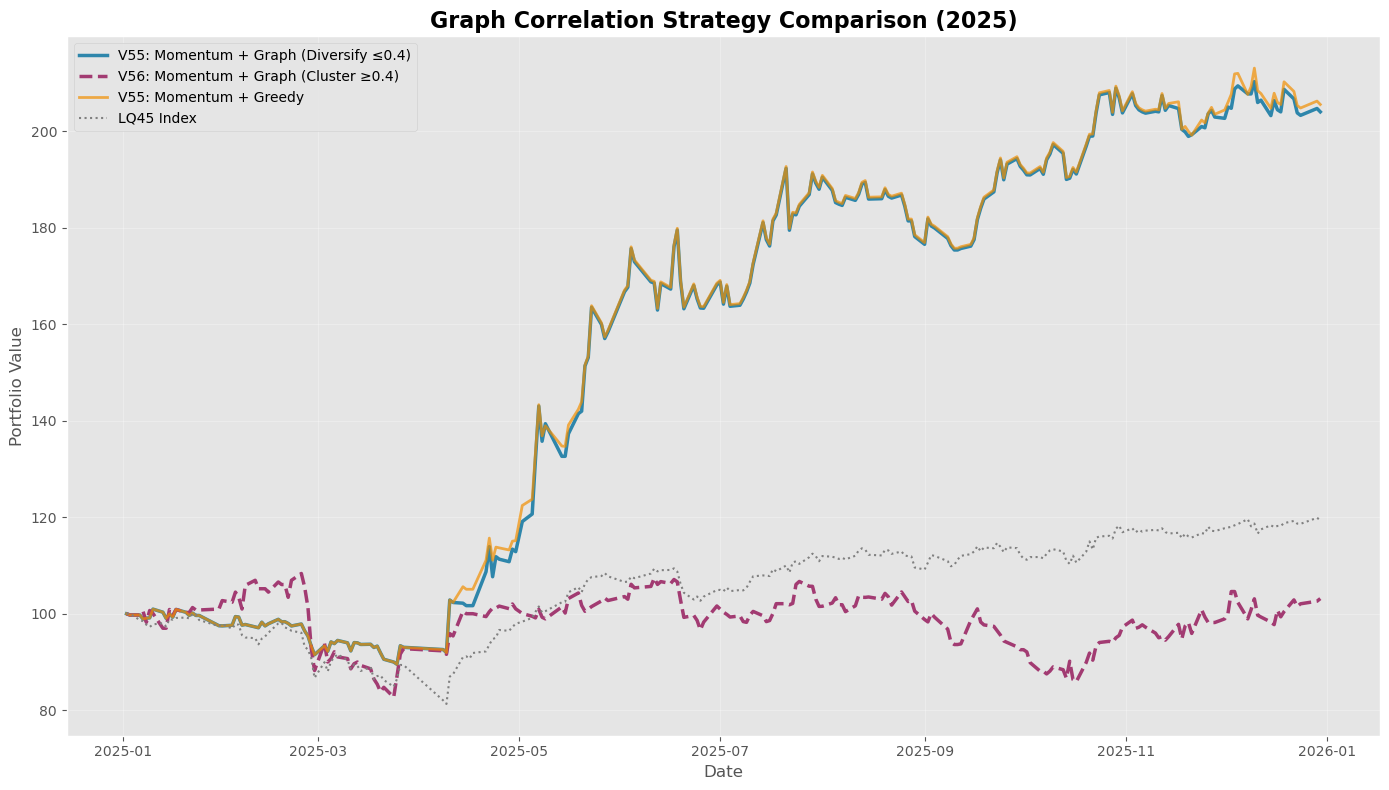


Visualization complete!


In [7]:
# Visualization

plt.figure(figsize=(14, 8))

plt.plot(v55_diversify.index, v55_diversify['Portfolio_Value'], 
         label='V55: Momentum + Graph (Diversify ≤0.4)', linewidth=2.5, color='#2E86AB')
plt.plot(v56_cluster.index, v56_cluster['Portfolio_Value'], 
         label='V56: Momentum + Graph (Cluster ≥0.4)', linewidth=2.5, color='#A23B72', linestyle='--')
plt.plot(v55_greedy.index, v55_greedy['Portfolio_Value'], 
         label='V55: Momentum + Greedy', linewidth=2, color='#F18F01', alpha=0.7)
plt.plot(lq45_idx.index, lq45_idx.values, 
         label='LQ45 Index', linewidth=1.5, color='gray', linestyle=':')

plt.title('Graph Correlation Strategy Comparison (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [8]:
# Calculate Risk Metrics

def calculate_metrics(portfolio_values):
    returns = portfolio_values.pct_change().dropna()
    
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

metrics_diversify = calculate_metrics(v55_diversify['Portfolio_Value'])
metrics_cluster = calculate_metrics(v56_cluster['Portfolio_Value'])
metrics_greedy = calculate_metrics(v55_greedy['Portfolio_Value'])
metrics_index = calculate_metrics(lq45_idx)

results_df = pd.DataFrame({
    'V55 Diversify (≤0.4)': metrics_diversify,
    'V56 Cluster (≥0.4)': metrics_cluster,
    'V55 Greedy': metrics_greedy,
    'LQ45 Index': metrics_index
}).T

print("\n=== RISK METRICS ===")
print(results_df.round(2))

# Export to Excel
output_file = 'v56_graph_correlation_comparison_results.xlsx'
results_df.to_excel(output_file)
print(f"\nResults exported to: {output_file}")


=== RISK METRICS ===
                      Total Return (%)  Volatility (%)  Sharpe Ratio  \
V55 Diversify (≤0.4)            104.07           35.52          2.33   
V56 Cluster (≥0.4)                3.15           31.12          0.26   
V55 Greedy                      105.60           33.91          2.45   
LQ45 Index                       19.44           20.38          1.04   

                      Max Drawdown (%)  
V55 Diversify (≤0.4)            -11.33  
V56 Cluster (≥0.4)              -23.68  
V55 Greedy                      -11.33  
LQ45 Index                      -18.70  

Results exported to: v56_graph_correlation_comparison_results.xlsx


## Kesimpulan

### Interpretasi Hasil:

1. **Diversifikasi (≤ 0.4)**:
   - Memilih aset dengan korelasi rendah
   - Tujuan: Mengurangi risiko sistematis
   - Expected: Volatilitas lebih rendah, Sharpe ratio lebih tinggi

2. **Clustering (≥ 0.4)**:
   - Memilih aset dengan korelasi tinggi
   - Tujuan: Menangkap momentum sektor
   - Expected: Return lebih tinggi (bullish), tapi risiko lebih besar

3. **Greedy (Baseline)**:
   - Sequential selection tanpa graph theory
   - Benchmark untuk kedua strategi graph

### Rekomendasi:
- Pilih **Diversifikasi** jika prioritas adalah risk-adjusted return
- Pilih **Clustering** jika yakin dengan trend momentum yang kuat
- Kombinasi keduanya bisa dipertimbangkan untuk regime-switching strategy